<a href="https://colab.research.google.com/github/pieupieu16/Predict_weekly_sales/blob/main/Predict_weekly_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noopurbhatt/retail-store-sales-forecasting-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.75M/2.75M [00:00<00:00, 141MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/noopurbhatt/retail-store-sales-forecasting-dataset/versions/3


In [ ]:
import os
import pandas as pd

sales=pd.read_csv(os.path.join(path, 'sales.csv'))
features=pd.read_csv(os.path.join(path, 'features.csv'))
stores=pd.read_csv(os.path.join(path, 'stores.csv'))

df=pd.merge(sales, features, on=['store_id','date','is_holiday'], how='left')
df=pd.merge(df, stores, on=['store_id'], how='left')
print(df.shape)
df=df.drop('date',axis=1)


(156000, 19)


Gộp thông tin đặc trưng (nhiệt độ, giá xăng...) và thông tin cửa hàng (loại cửa hàng, kích thước) vào bảng doanh thu theo các khóa định danh trùng khớp để mô hình có đầy đủ ngữ cảnh dự đoán.

In [ ]:
df.columns.to_list()

['store_id',
 'department',
 'weekly_sales',
 'is_holiday',
 'temperature',
 'fuel_price',
 'markdown_1',
 'markdown_2',
 'markdown_3',
 'markdown_4',
 'markdown_5',
 'cpi',
 'unemployment',
 'holiday_name',
 'season',
 'store_type',
 'store_size',
 'region']

# EDA basic

Viết hàm check để dễ kiểm tra không phải viết lại nhiều lần

In [ ]:
def check(df):
    total_rows = len(df)
    duplicates = df.duplicated().sum()

    dtypes = df.dtypes
    instances = df.count()
    unique = df.nunique()
    sum_null = df.isnull().sum()

    df_check = pd.DataFrame({
        'column': df.columns,
        'dtype': dtypes,
        'instances': instances,
        'unique': unique,
        'sum_null': sum_null,
        'duplicates': duplicates
    })

    return df_check

In [ ]:
check(df)

,column,dtype,instances,unique,sum_null,duplicates
store_id,store_id,int64,156000,50,0,0
department,department,int64,156000,20,0,0
weekly_sales,weekly_sales,float64,156000,154981,0,0
is_holiday,is_holiday,int64,156000,2,0,0
temperature,temperature,float64,156000,4974,0,0
fuel_price,fuel_price,float64,156000,301,0,0
markdown_1,markdown_1,float64,156000,7740,0,0
markdown_2,markdown_2,float64,156000,7722,0,0
markdown_3,markdown_3,float64,156000,7740,0,0
markdown_4,markdown_4,float64,156000,7733,0,0


Kiểm tra có dữ liệu nào bị sai định dạng

In [ ]:
df.head(5)

,store_id,department,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,holiday_name,season,store_type,store_size,region
0,1,1,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
1,1,2,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
2,1,3,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
3,1,4,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
4,1,5,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store_id      156000 non-null  int64  
 1   department    156000 non-null  int64  
 2   weekly_sales  156000 non-null  float64
 3   is_holiday    156000 non-null  int64  
 4   temperature   156000 non-null  float64
 5   fuel_price    156000 non-null  float64
 6   markdown_1    156000 non-null  float64
 7   markdown_2    156000 non-null  float64
 8   markdown_3    156000 non-null  float64
 9   markdown_4    156000 non-null  float64
 10  markdown_5    156000 non-null  float64
 11  cpi           156000 non-null  float64
 12  unemployment  156000 non-null  float64
 13  holiday_name  18000 non-null   object 
 14  season        156000 non-null  object 
 15  store_type    156000 non-null  object 
 16  store_size    156000 non-null  int64  
 17  region        156000 non-null  object 
dtypes: f

phát hiện cột holiday_name thiếu quá nhiều

In [ ]:
df['holiday_name'].unique()

array(['New Year', nan, 'Independence Day', 'Labor Day', 'Black Friday',
       'Christmas'], dtype=object)

đối với mục tiêu dự đoán doanh thu thì những biến này vẫn quan trọng

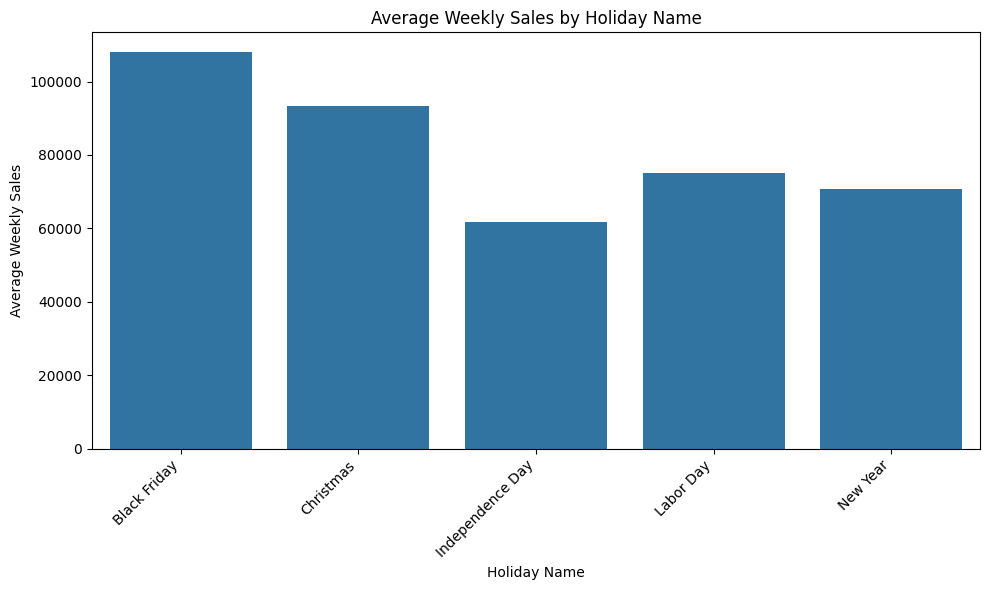

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

holiday_sales = df.groupby('holiday_name')['weekly_sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='holiday_name', y='weekly_sales', data=holiday_sales)
plt.title('Average Weekly Sales by Holiday Name')
plt.xlabel('Holiday Name')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
holiday_sales

,holiday_name,weekly_sales
0,Black Friday,107997.574382
1,Christmas,93292.635820
2,Independence Day,61704.270840
3,Labor Day,74964.674730
4,New Year,70809.514853


Xem từng giá trị unique có gì đặc biệt

In [ ]:
for column in df.columns:
    print(f"Unique values for column '{column}':\n{df[column].unique()}\n")

Unique values for column 'store_id':
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]

Unique values for column 'department':
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Unique values for column 'weekly_sales':
[119075.96 119107.85  84369.88 ... 102313.34 233651.09 212747.49]

Unique values for column 'is_holiday':
[1 0]

Unique values for column 'temperature':
[97.57 46.03 25.96 ... 60.16 50.3  75.43]

Unique values for column 'fuel_price':
[4.83 3.67 5.46 3.58 4.41 4.07 3.25 4.4  2.83 2.86 3.26 5.22 4.68 2.62
 3.66 4.95 3.55 4.32 3.17 2.78 4.01 5.32 5.06 4.21 4.61 4.89 2.61 2.88
 2.58 4.64 3.57 2.79 3.62 4.26 5.38 3.46 4.71 4.02 5.35 4.87 2.85 4.62
 4.76 2.53 4.08 4.38 3.33 4.11 4.34 2.95 2.67 3.24 2.84 3.71 4.37 3.98
 4.42 3.01 4.57 4.92 4.74 4.1  5.17 3.79 3.21 2.74 3.27 3.47 3.94 5.4
 2.92 5.13 3.2  3.5  5.04 4.58 5.34 4.59 5.28 4.27 5.26 4.   3.13 3.86
 2.8 

In [ ]:
df.shape

(156000, 18)

In [ ]:
num_data=df.select_dtypes(exclude='object')
num_data.head()

,store_id,department,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,store_size
0,1,1,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,213810
1,1,2,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,213810
2,1,3,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,213810
3,1,4,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,213810
4,1,5,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,213810


Xem phân phối dữ liệu để biết nên điền gì khi biến xuất hiện dòng bị thiếu

In [ ]:
num_data.describe()

,store_id,department,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,store_size
count,156000.000000,156000.0000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000
mean,25.500000,10.5000,56503.488802,0.115385,59.875755,3.986344,2831.840176,1708.091033,2295.922200,1982.042679,2561.790629,240.469559,6.485572,136626.440000
std,14.430916,5.7663,46717.490663,0.319487,23.114765,0.864025,1977.833293,1187.621364,1579.278801,1351.446660,1769.691198,34.600848,2.014998,53081.473652
min,1.000000,1.0000,819.660000,0.000000,20.020000,2.500000,0.180000,0.200000,1.010000,1.130000,0.140000,180.000000,3.000000,31639.000000
25%,13.000000,5.7500,21255.962500,0.000000,39.942500,3.240000,1308.727500,787.155000,1095.917500,969.917500,1198.375000,211.027500,4.720000,91417.000000
50%,25.500000,10.5000,43394.870000,0.000000,60.065000,3.970000,2652.495000,1612.570000,2174.595000,1862.980000,2417.900000,240.945000,6.490000,140736.500000
75%,38.000000,15.2500,79604.107500,0.000000,79.910000,4.750000,4027.545000,2423.002500,3212.695000,2790.137500,3600.245000,270.445000,8.220000,179797.000000
max,50.000000,20.0000,505958.730000,1.000000,99.970000,5.500000,10977.070000,6599.720000,8798.150000,7692.880000,9891.190000,299.990000,10.000000,218696.000000


Xem phân phối của dữ liệu để chọn thuật toán phù hợp

In [ ]:

def visualize_numberic_feature(data_frame, col_name):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(data =  data_frame ,x = col_name,  ax=ax[0])
    sns.boxplot(data =  data_frame ,y = col_name,  ax=ax[1])

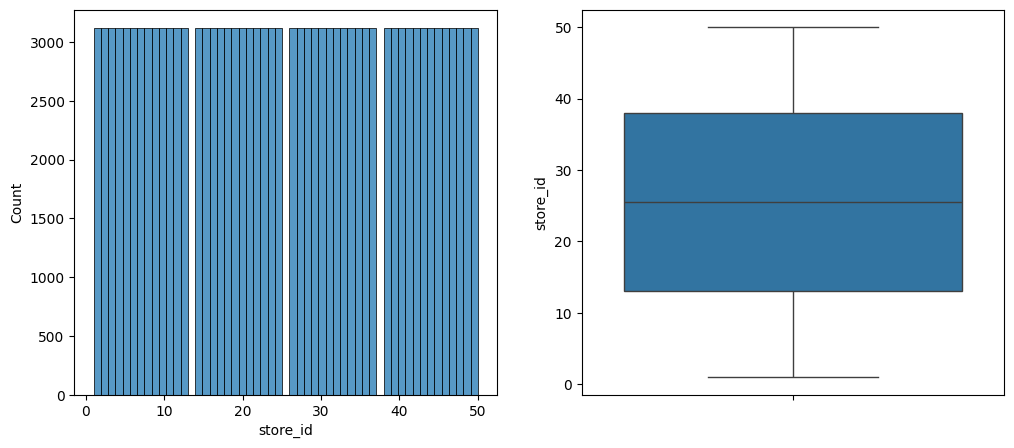

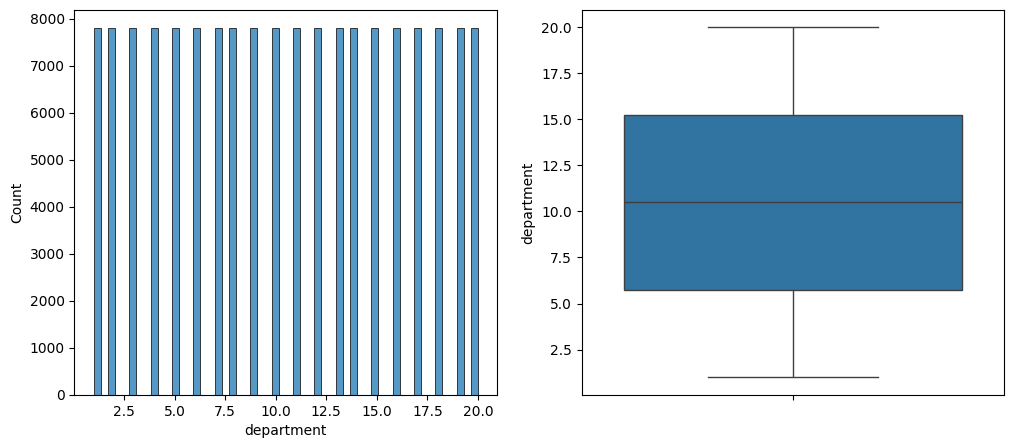

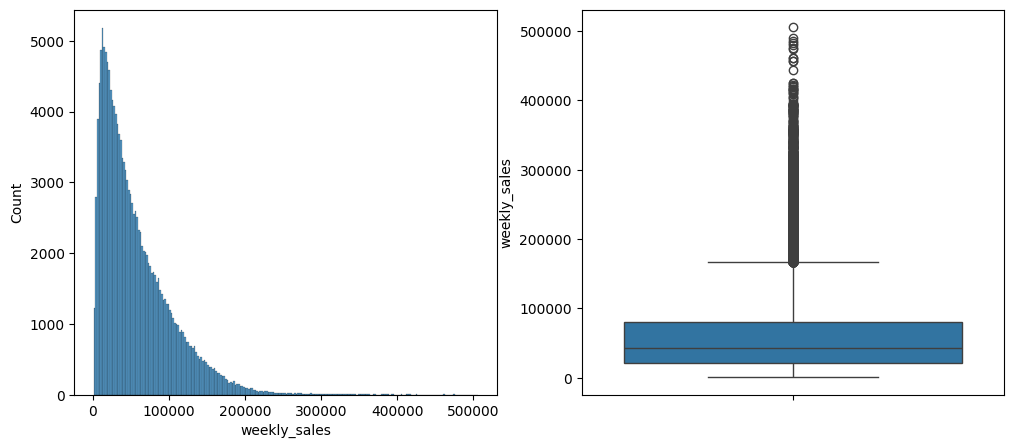

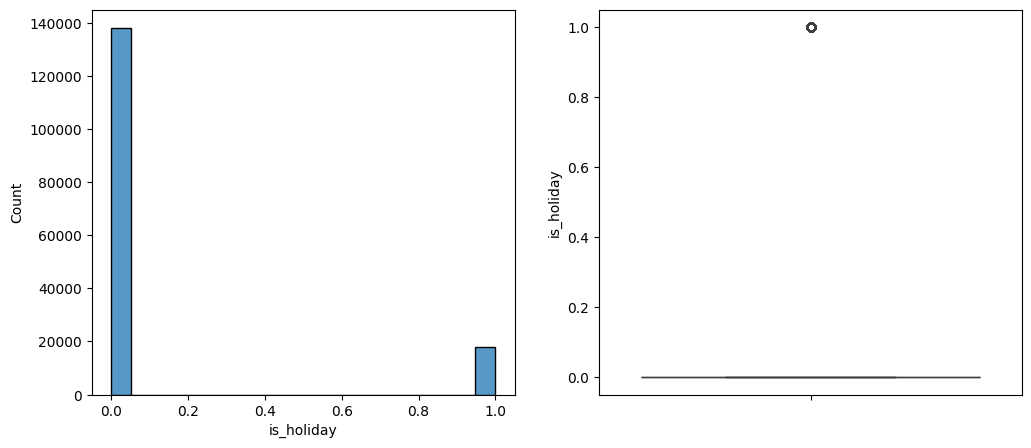

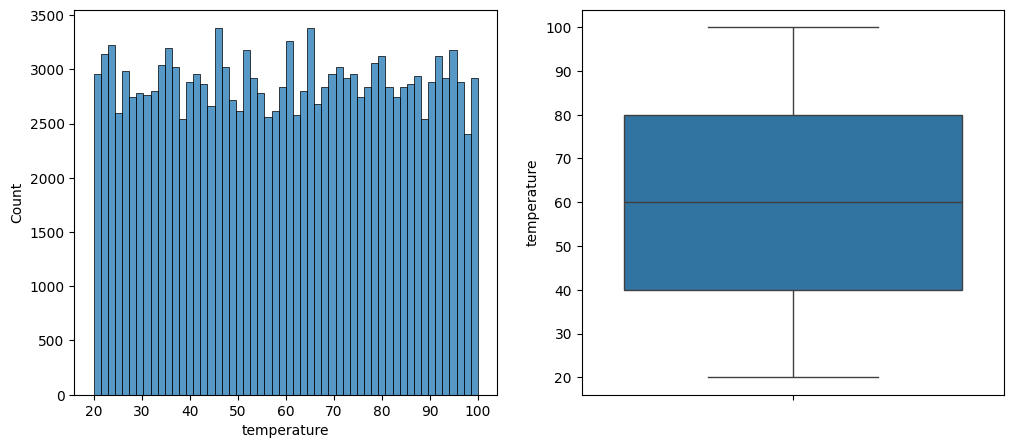

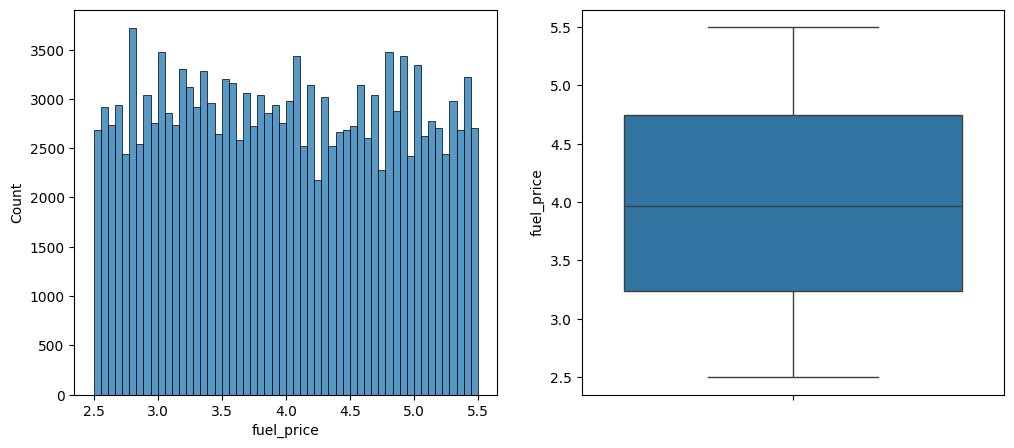

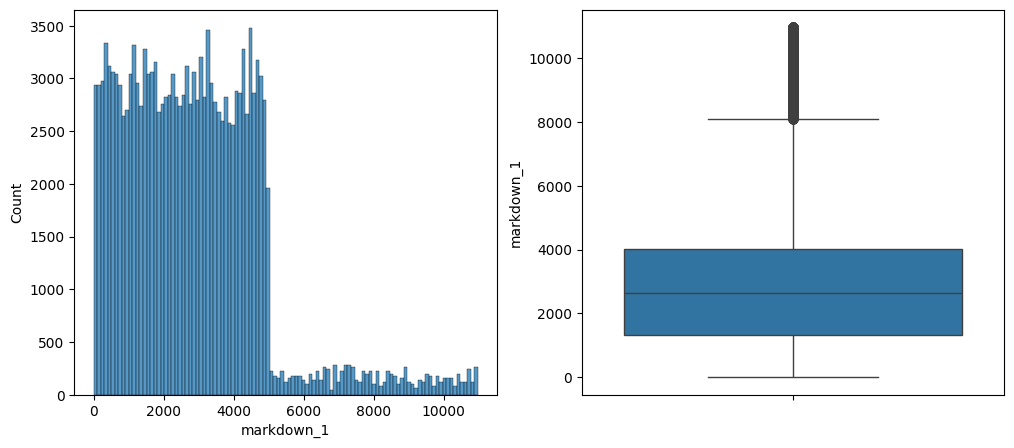

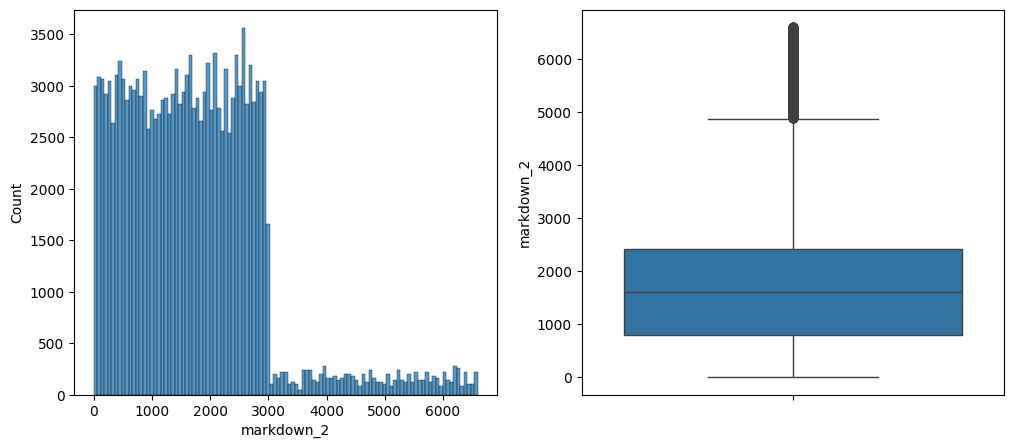

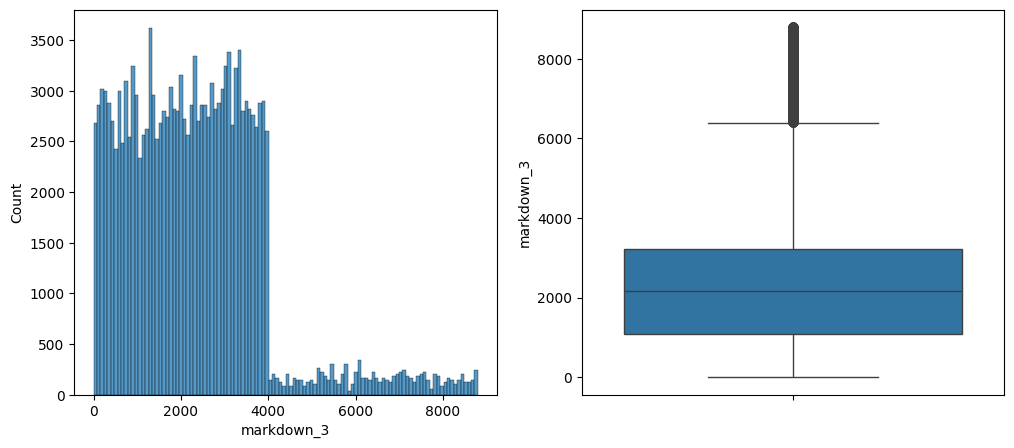

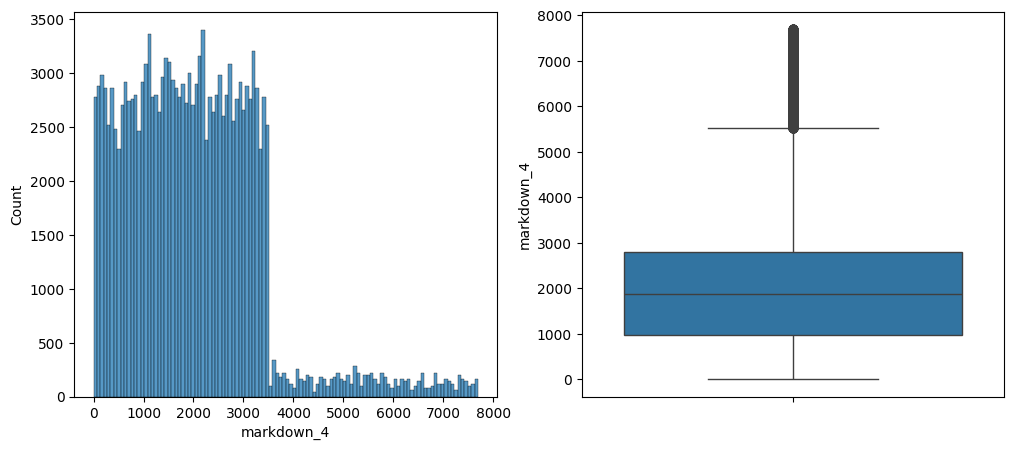

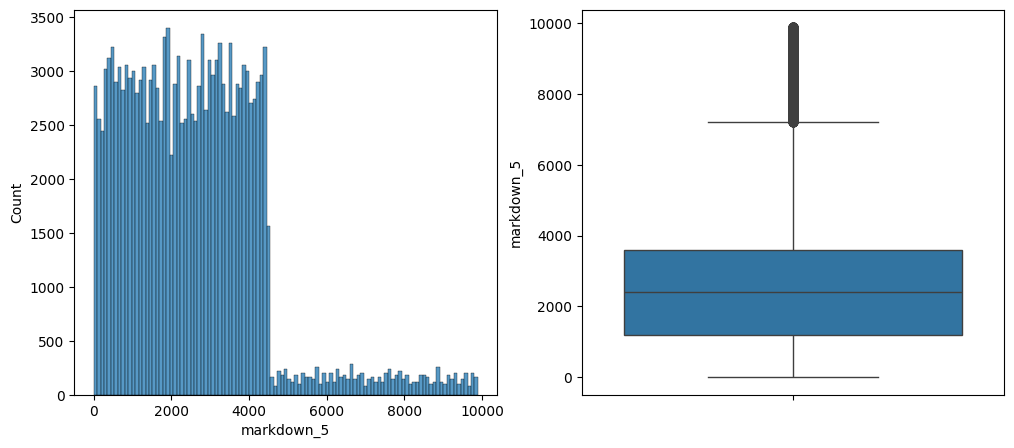

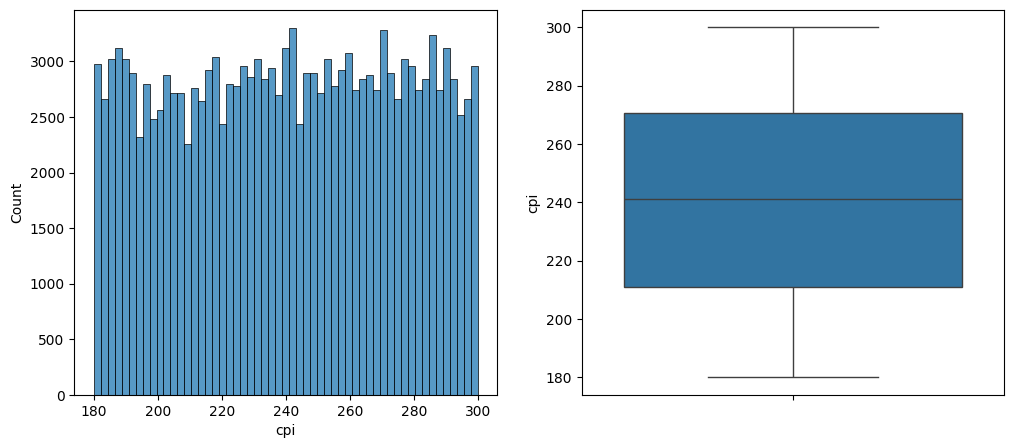

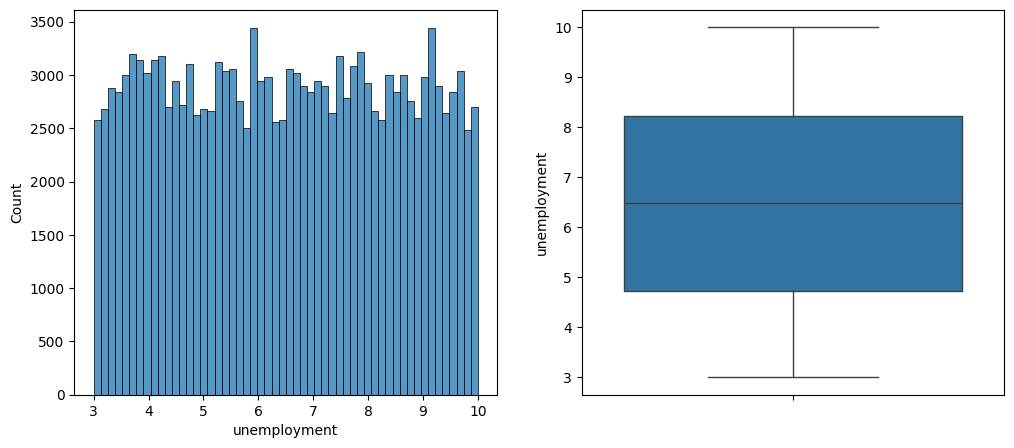

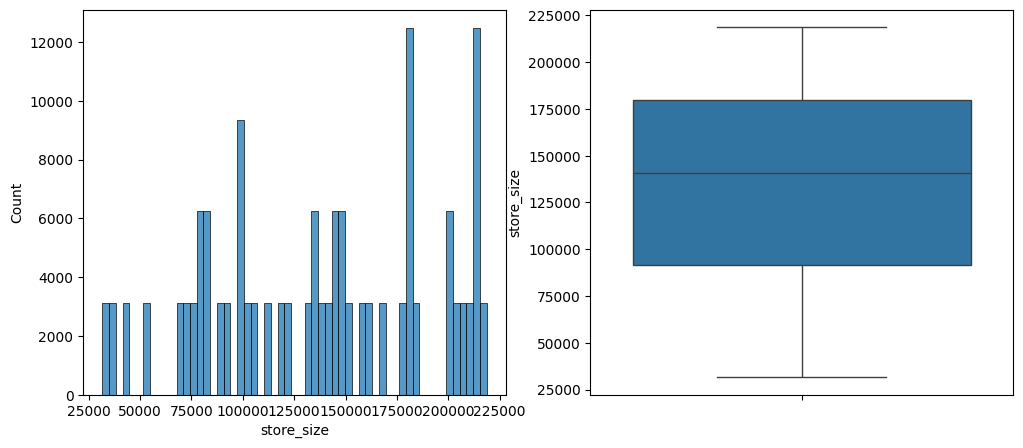

In [ ]:
for col in num_data.columns:
    visualize_numberic_feature(num_data, col)

- > taget bị lệch phải -> cần phải xử lí
- > cần chuẩn hóa các feauture về cùng một thang đo
- > nhiều outline


kiểm tra dữ liệu categorical

In [ ]:
object_data=df.select_dtypes(include='object')
object_data.head()


,holiday_name,season,store_type,region
0,New Year,Winter,A,North
1,New Year,Winter,A,North
2,New Year,Winter,A,North
3,New Year,Winter,A,North
4,New Year,Winter,A,North


In [ ]:
object_data.describe()

,holiday_name,season,store_type,region
count,18000,156000,156000,156000
unique,5,4,3,4
top,Christmas,Summer,A,East
freq,5000,40000,81120,49920


In [ ]:
object_data.isnull().sum()

,0
holiday_name,138000
season,0
store_type,0
region,0


In [ ]:
object_data['season'].value_counts()

,count
season,
Summer,40000
Spring,39000
Fall,39000
Winter,38000


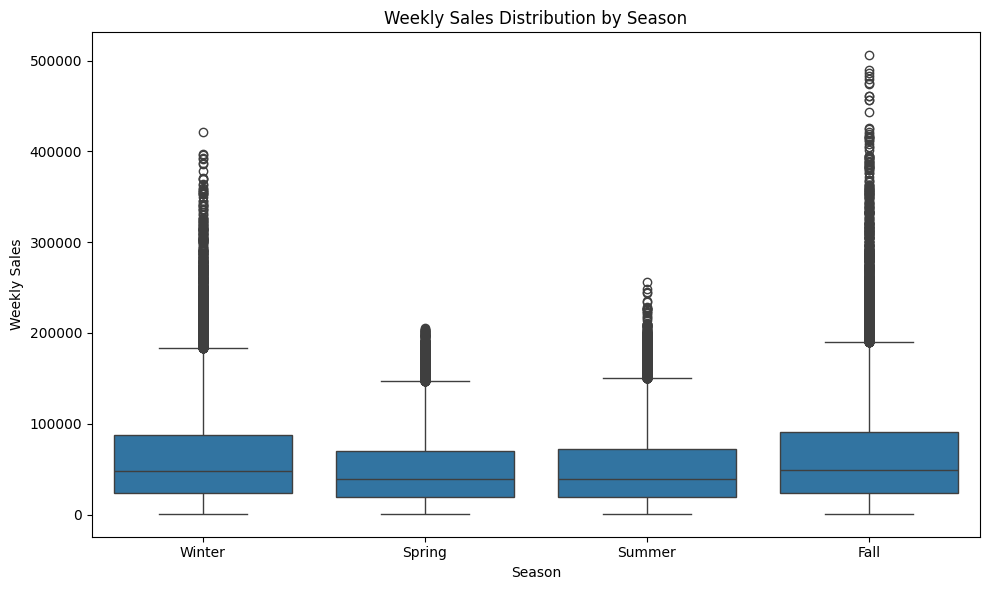

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='weekly_sales', data=df)
plt.title('Weekly Sales Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

In [ ]:
object_data['region'].value_counts()

,count
region,
East,49920
North,40560
South,37440
West,28080


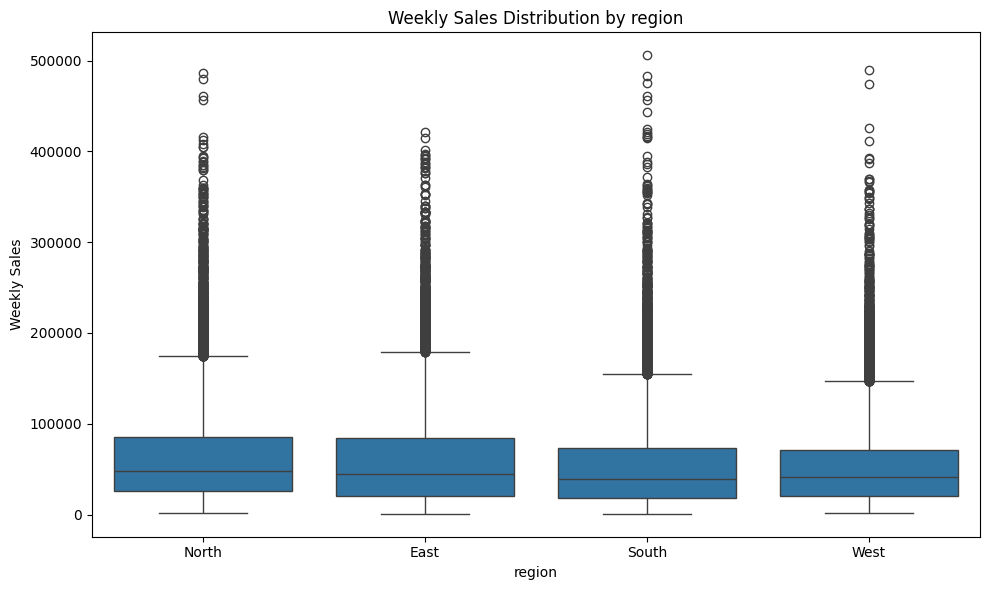

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='weekly_sales', data=df)
plt.title('Weekly Sales Distribution by region')
plt.xlabel('region')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

In [ ]:
object_data['store_type'].value_counts()

,count
store_type,
A,81120
B,49920
C,24960


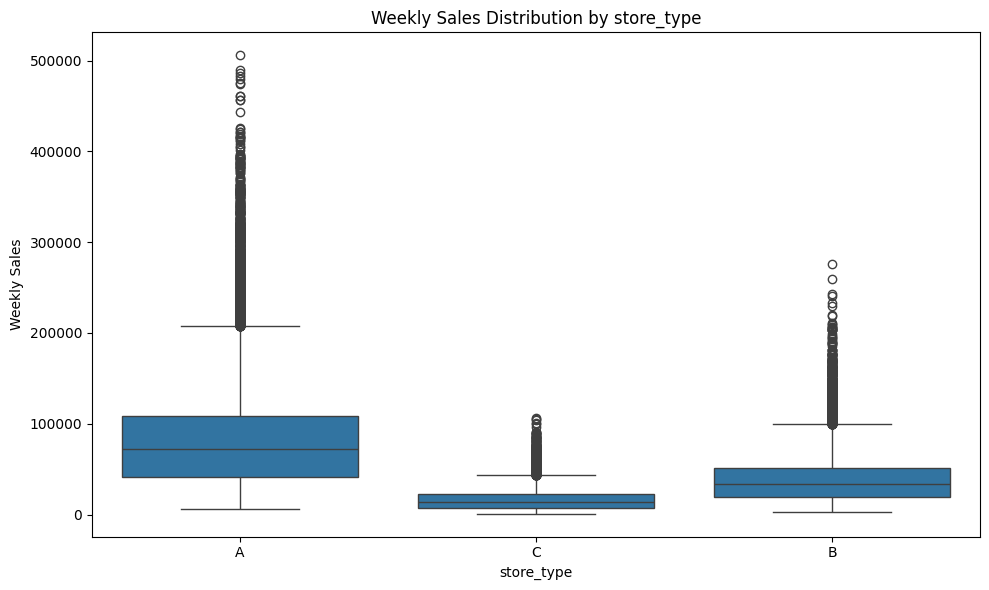

In [ ]:


plt.figure(figsize=(10, 6))
sns.boxplot(x='store_type', y='weekly_sales', data=df)
plt.title('Weekly Sales Distribution by store_type')
plt.xlabel('store_type')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

In [ ]:
object_data['holiday_name'].value_counts()

,count
holiday_name,
Christmas,5000
Black Friday,4000
New Year,3000
Labor Day,3000
Independence Day,3000


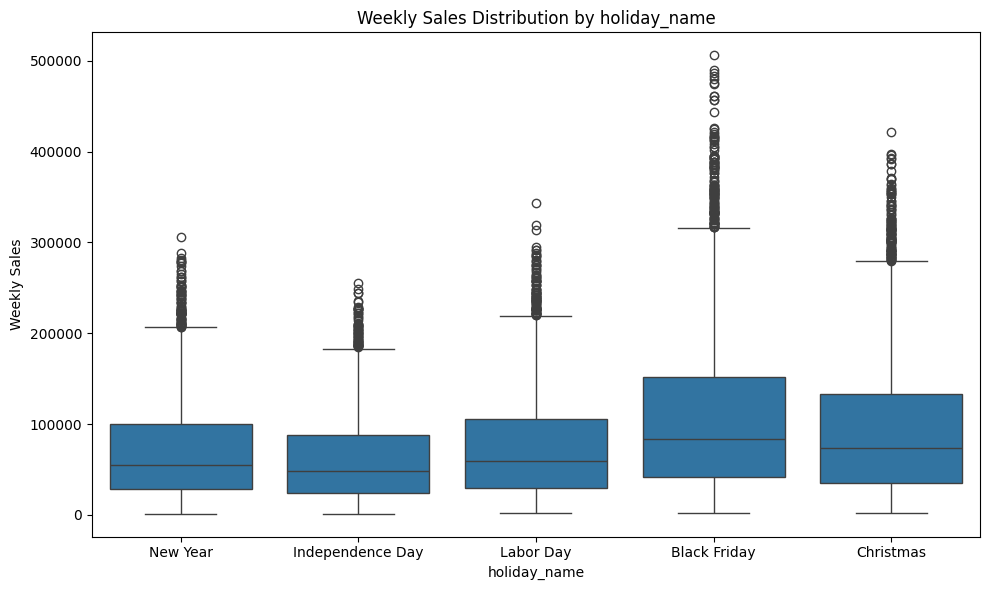

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='holiday_name', y='weekly_sales', data=df)
plt.title('Weekly Sales Distribution by holiday_name')
plt.xlabel('holiday_name')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

In [ ]:
df_lgb = df.copy()

# Chia Train/test

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['weekly_sales'])
y = df['weekly_sales']

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)

# Xử lí dữ liệu thô


## Vấn đề  cột Taget( weekly_sales ) bị lệch phải

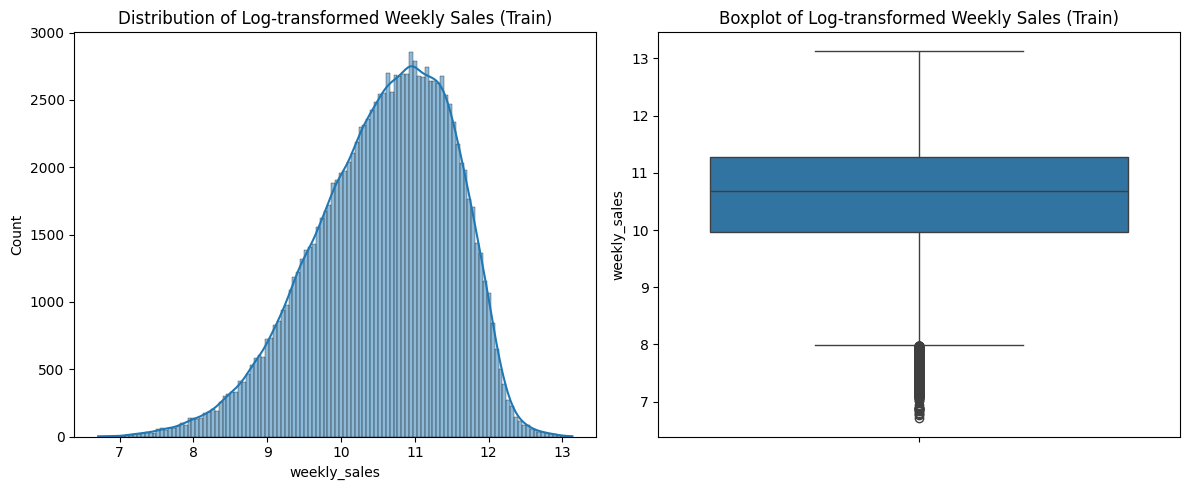

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


y_train_log = np.log1p(y_train_log)
y_test_log = np.log1p(y_test_log)



plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y_train_log, kde=True)
plt.title('Distribution of Log-transformed Weekly Sales (Train)')

plt.subplot(1, 2, 2)
sns.boxplot(y=y_train_log)
plt.title('Boxplot of Log-transformed Weekly Sales (Train)')
plt.tight_layout()
plt.show()

Xử lí vấn đề thiếu dữ liệu cột holiday_name đề xuất 2 phương án
- Điền Nan thành Normal Day rồi one-hot -> Nhược điểm dữ liệu quá lớn gây đa cộng tuyến và lời nguyền đa chiều
- Thay thế tên của từng ngày lễ và ngày thường bằng chính giá trị doanh thu trung bình của ngày lễ đó (Target Encoding / Mean Encoding) -> ảnh hưởng tuyến tính

In [ ]:

import pandas as pd

categorical_cols = object_data.columns.tolist()
X_train['holiday_name'] = X_train['holiday_name'].fillna('Normal Day')
X_test['holiday_name'] = X_test['holiday_name'].fillna('Normal Day')


In [ ]:
df.head()

,store_id,department,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,holiday_name,season,store_type,store_size,region
0,1,1,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
1,1,2,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
2,1,3,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
3,1,4,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
4,1,5,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North


Kiểm tra xem x_train và x_test có cùng unique không ,cùng định dạng

In [ ]:
check(X_train)

,column,dtype,instances,unique,sum_null,duplicates
store_id,store_id,int64,124800,50,0,0
department,department,int64,124800,20,0,0
is_holiday,is_holiday,int64,124800,2,0,0
temperature,temperature,float64,124800,4974,0,0
fuel_price,fuel_price,float64,124800,301,0,0
markdown_1,markdown_1,float64,124800,7740,0,0
markdown_2,markdown_2,float64,124800,7722,0,0
markdown_3,markdown_3,float64,124800,7740,0,0
markdown_4,markdown_4,float64,124800,7733,0,0
markdown_5,markdown_5,float64,124800,7728,0,0


In [ ]:
check(X_test)

,column,dtype,instances,unique,sum_null,duplicates
store_id,store_id,int64,31200,50,0,0
department,department,int64,31200,20,0,0
is_holiday,is_holiday,int64,31200,2,0,0
temperature,temperature,float64,31200,4939,0,0
fuel_price,fuel_price,float64,31200,301,0,0
markdown_1,markdown_1,float64,31200,7658,0,0
markdown_2,markdown_2,float64,31200,7639,0,0
markdown_3,markdown_3,float64,31200,7656,0,0
markdown_4,markdown_4,float64,31200,7649,0,0
markdown_5,markdown_5,float64,31200,7644,0,0


không có dữ liệu trùng lặp

# Encoding cho các biến object còn lại

Đối với mô hình hồi quy tuyến tính, em lựa chọn phương pháp One-Hot Encoding kết hợp với drop_first=True thay vì Target Encoding. Nguyên do là vì mô hình tuyến tính yêu cầu các biến độc lập không có tính thứ tự nhân tạo và không xảy ra hiện tượng đa cộng tuyến. One-Hot Encoding giúp cô lập tác động của từng danh mục thành các hệ số độc lập, phản ánh đúng cơ chế toán học của phương trình hồi quy.

In [ ]:
object_data=df.select_dtypes(include='object')
object_list=object_data.columns.to_list()
print(object_list)

['holiday_name', 'season', 'store_type', 'region']


In [ ]:

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Ma trận tương quan

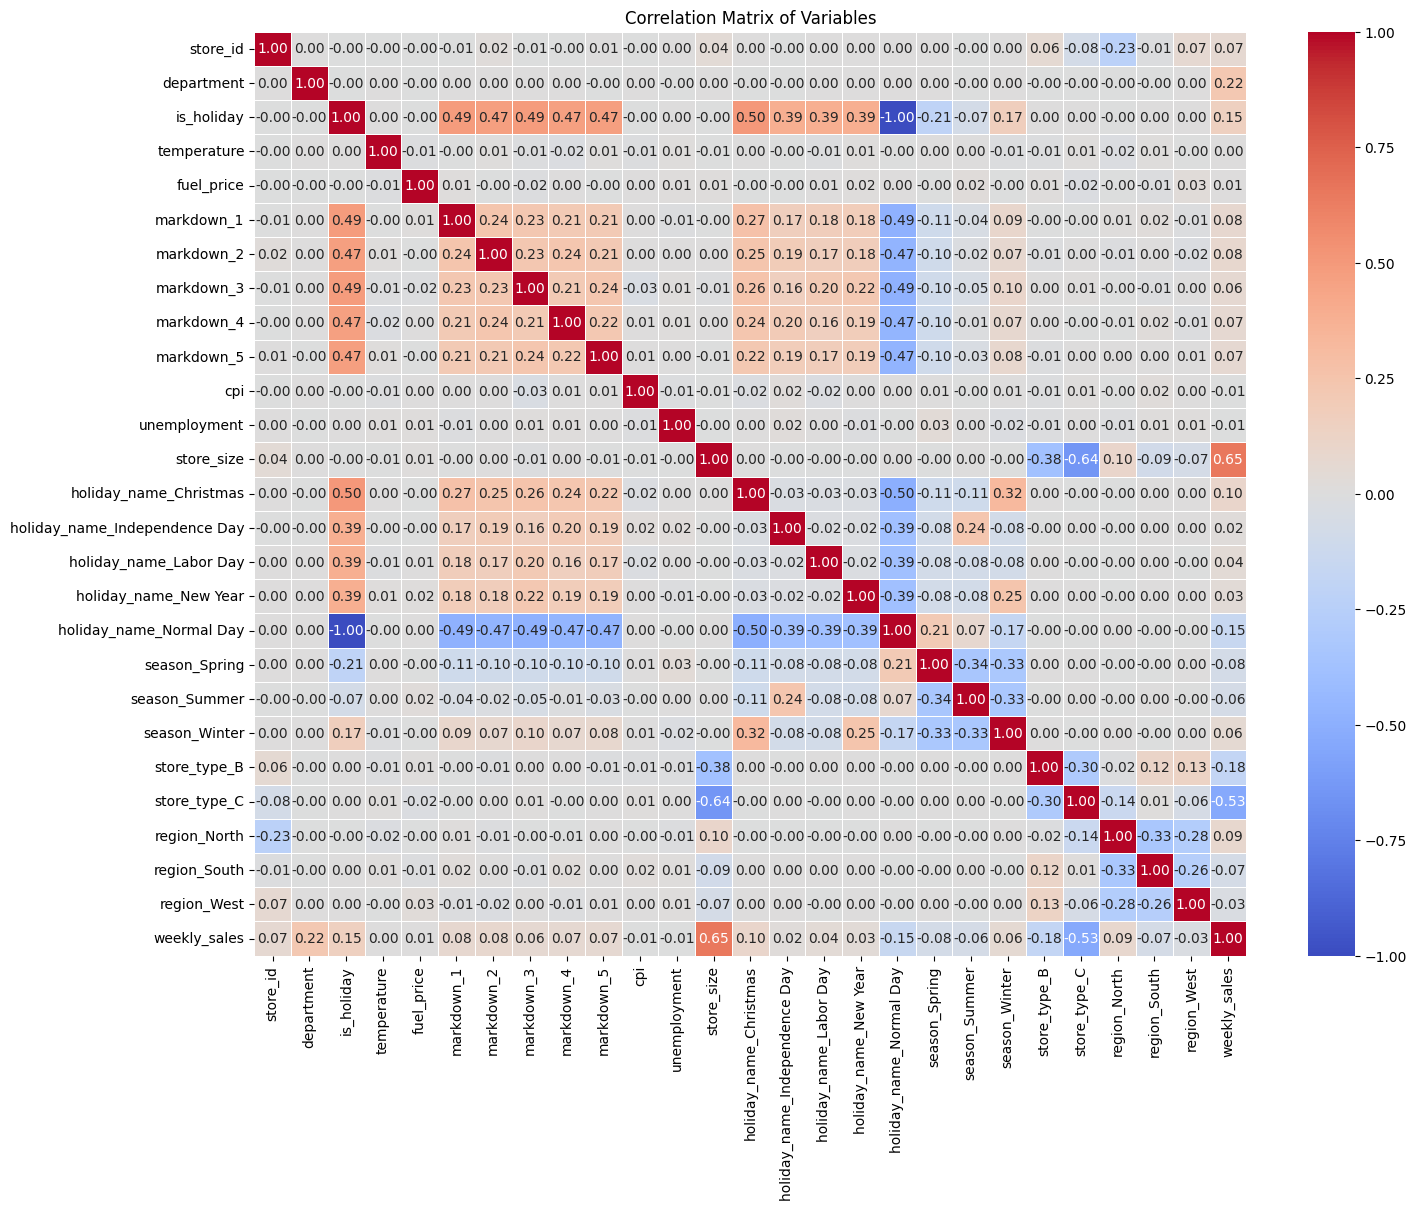

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
train_analysis_df = X_train_encoded.copy()
train_analysis_df['weekly_sales'] = y_train_log
correlation_matrix = train_analysis_df.corr()


plt.figure(figsize=(16, 12))


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Variables')
plt.show()

In [ ]:
train_analysis_df.describe()

,store_id,department,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,store_size,weekly_sales
count,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000,124800.000000
mean,25.463309,10.513301,0.115192,59.901691,3.988865,2828.651350,1707.110108,2295.327384,1982.683148,2560.653614,240.514611,6.487668,136539.949888,10.574351
std,14.443374,5.762703,0.319255,23.106164,0.864117,1975.421197,1187.501706,1579.371278,1350.766542,1770.587964,34.591548,2.016984,53101.629649,0.932769
min,1.000000,1.000000,0.000000,20.020000,2.500000,0.180000,0.200000,1.010000,1.130000,0.140000,180.000000,3.000000,31639.000000,6.710109
25%,13.000000,6.000000,0.000000,40.040000,3.240000,1307.930000,784.040000,1095.240000,970.060000,1196.100000,211.040000,4.720000,91417.000000,9.962608
50%,25.000000,11.000000,0.000000,60.090000,3.970000,2649.940000,1609.870000,2174.210000,1863.700000,2417.440000,241.010000,6.490000,139116.000000,10.676231
75%,38.000000,16.000000,0.000000,79.910000,4.750000,4027.620000,2420.740000,3212.580000,2791.460000,3596.960000,270.440000,8.220000,179797.000000,11.284462
max,50.000000,20.000000,1.000000,99.970000,5.500000,10977.070000,6599.720000,8798.150000,7692.880000,9891.190000,299.990000,10.000000,218696.000000,13.134212


# Chuẩn hóa dữ liệu

Có 3 phương pháp chuẩn hóa thường dùng:
- Min-Max Scaling : loại vì như biểu đồ boxplot ở trên thì bộ dữ liệu có khá nhiều outline.
- Standardization : loại vì biểu đồ hist ở trên cho thấy dữ liệu không / ít có phân phối chuẩn và outline vẫn có ảnh hưởng .
- Robust Scaling : Chọn vì đây lầ giải pháp tối ưu cho outliner và hai phương án trên không xử lí được

In [ ]:
from sklearn.preprocessing import RobustScaler


scaler = RobustScaler()


X_train_scaled = scaler.fit_transform(X_train_encoded)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)


X_test_scaled = scaler.transform(X_test_encoded)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns, index=X_test_encoded.index)

print("Dữ liệu huấn luyện đã được chuẩn hóa (Robust Scaled):")
print(X_train_scaled.head())
print("\nDữ liệu kiểm tra đã được chuẩn hóa (Robust Scaled):")
print(X_test_scaled.head())

Dữ liệu huấn luyện đã được chuẩn hóa (Robust Scaled):
        store_id  department  is_holiday  temperature  fuel_price  markdown_1  \
81165       0.08        -0.5         0.0     0.487585    0.880795   -0.682898   
93015       0.20         0.5         0.0     0.675947   -0.344371   -0.087738   
113648      0.48        -0.2         0.0     0.391272   -0.794702    0.638558   
145574      0.88         0.4         0.0    -0.496363   -0.033113    0.009310   
116165      0.52        -0.5         0.0     0.675445    0.370861    0.840644   

        markdown_2  markdown_3  markdown_4  markdown_5  ...  \
81165    -0.129773   -0.431277   -0.337707   -0.246383  ...   
93015    -0.087951    0.140662    0.675502   -0.681635  ...   
113648    0.004387    0.713490   -0.167196    0.273419  ...   
145574    0.578420    0.029221   -0.537608    0.019364  ...   
116165    0.528050   -0.646193   -0.160421   -0.812896  ...   

        holiday_name_New Year  holiday_name_Normal Day  season_Spring  \
81165  

# Chuẩn bị dữ liệu để huấn luyện mô hình

In [ ]:

train_analysis_df = X_train_encoded.copy()
train_analysis_df['weekly_sales'] = y_train_log

correlations = train_analysis_df.corr()['weekly_sales']

positive_corr_features = correlations[correlations > -2].index.tolist()


if 'weekly_sales' in positive_corr_features:
    positive_corr_features.remove('weekly_sales')

X_train_linear= X_train_scaled[positive_corr_features].copy()
X_test_linear = X_test_scaled[positive_corr_features].copy()

print(f"Đã tạo tập dữ liệu tuyến tính với {len(positive_corr_features)} đặc trưng tương quan dương.")
print("Các đặc trưng được chọn:", positive_corr_features)

Đã tạo tập dữ liệu tuyến tính với 26 đặc trưng tương quan dương.
Các đặc trưng được chọn: ['store_id', 'department', 'is_holiday', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'store_size', 'holiday_name_Christmas', 'holiday_name_Independence Day', 'holiday_name_Labor Day', 'holiday_name_New Year', 'holiday_name_Normal Day', 'season_Spring', 'season_Summer', 'season_Winter', 'store_type_B', 'store_type_C', 'region_North', 'region_South', 'region_West']


# Xây dựng mô hình

Bắt đầu với thuật toán tuyến tính để xem xét với những feature tuyến tính thì có thể dự đoán ra doanh thu không

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


model = LinearRegression()
model.fit(X_train_linear, y_train_log)


y_train_pred = model.predict(X_train_linear)


rmse_train = np.sqrt(mean_squared_error(y_train_log, y_train_pred))
mae_train = mean_absolute_error(y_train_log, y_train_pred)
r2_train = r2_score(y_train_log, y_train_pred)
print(f"R-squared (Accuracy): {r2_train:.4f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE: {mae_train:.2f}")


y_test_pred = model.predict(X_test_linear)

rmse_test = np.sqrt(mean_squared_error(y_test_log, y_test_pred))
mae_test = mean_absolute_error(y_test_log, y_test_pred)
r2_test = r2_score(y_test_log, y_test_pred)

print(f"\n--- Testing Set Metrics ---")
print(f"R-squared (Accuracy): {r2_test:.4f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")

R-squared (Accuracy): 0.5372
RMSE: 0.63
MAE: 0.52

--- Testing Set Metrics ---
R-squared (Accuracy): 0.5414
RMSE: 0.63
MAE: 0.52


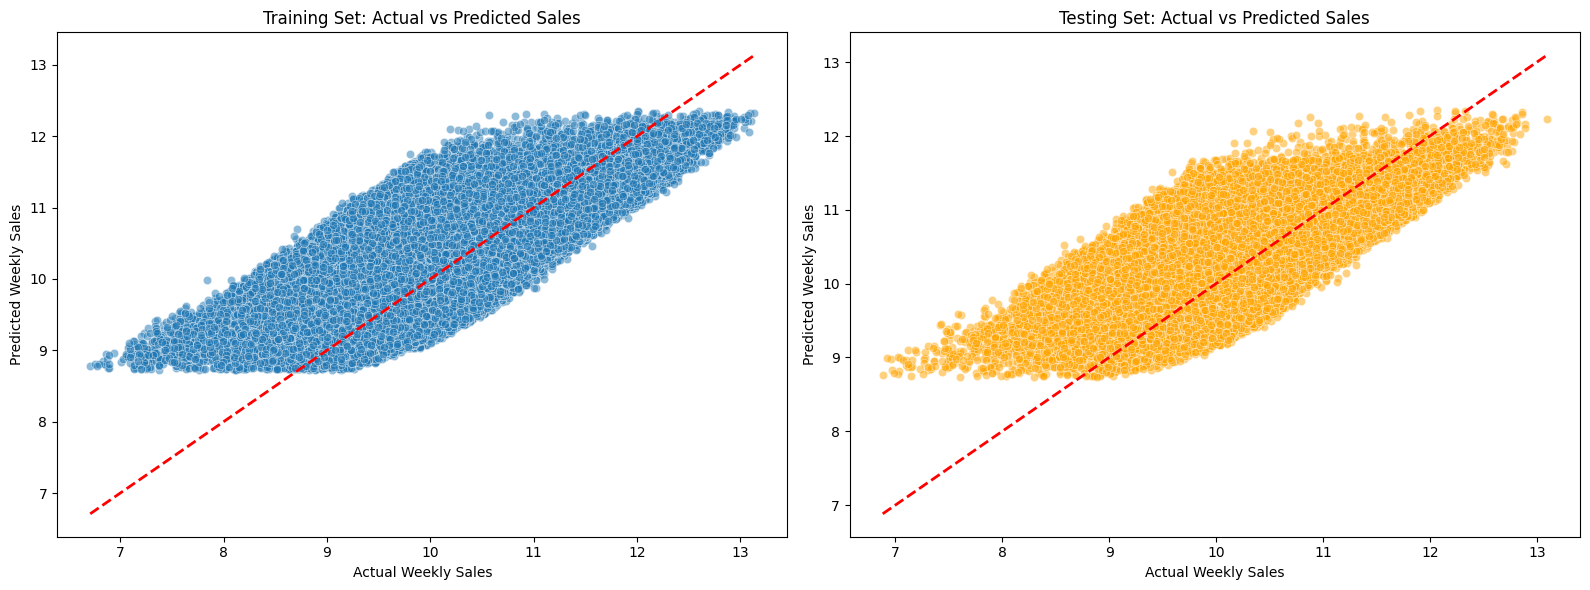

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_log, y=y_train_pred, alpha=0.5)

plt.plot([y_train_log.min(), y_train_log.max()], [y_train_log.min(), y_train_log.max()], color='red', linestyle='--', lw=2)
plt.title('Training Set: Actual vs Predicted Sales')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')


plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_log, y=y_test_pred, alpha=0.5, color='orange')

plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], color='red', linestyle='--', lw=2)
plt.title('Testing Set: Actual vs Predicted Sales')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Model Coefficients ---")

all_model_features = X_train_linear.columns
all_coefficients_df = pd.DataFrame({'Feature': all_model_features, 'Coefficient': model.coef_})


coefficients = all_coefficients_df[all_coefficients_df['Feature'].isin(positive_corr_features)]

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.to_string(index=False))


--- Model Coefficients ---
                      Feature  Coefficient
                   store_size     0.662810
                   department     0.359736
                   is_holiday     0.302217
                     store_id     0.054065
                 region_North     0.009569
                  temperature     0.006905
                   markdown_2     0.006038
                          cpi     0.002041
                   fuel_price     0.001507
                   markdown_4     0.000099
                   markdown_3    -0.000089
                   markdown_1    -0.000825
                   markdown_5    -0.005629
                 unemployment    -0.007657
                  region_West    -0.023822
                 region_South    -0.033127
                season_Winter    -0.038356
       holiday_name_Christmas    -0.098753
                season_Summer    -0.169394
                season_Spring    -0.171177
                 store_type_B    -0.204766
      holiday_name_Normal 

Mỗi hệ số đại diện cho sự thay đổi của 'weekly_sales' (doanh số hàng tuần) khi có sự tăng lên một đơn vị của yếu tố tương ứng, trong khi giữ các yếu tố khác không đổi. Các yếu tố có hệ số tuyệt đối lớn hơn sẽ có tác động lớn hơn đến doanh số dự đoán. Hệ số dương chỉ ra mối quan hệ đồng biến, trong khi hệ số âm chỉ ra mối quan hệ nghịch biến.

Vì sao hệ số tuyến tính rất cao(0.59) nhưng thuật cho ra kết quả rất thấp ( 0.5414)
* Do có quá nhiều outliers (LinearRegression sử dụng hàm mất mát bình phương tối thiểu) do đó đường tuyến tính sẽ bị kêos lệch khỏi quỹ đạo (dẫn chứng : Biều đồ boxplot )
* Dữ liệu vốn phi tuyến tính

## Vì đặc đù của bộ dữ liệu

*   Mối quan hệ giữa các biến là phi tuyến và phức tạp

*   Dữ liệu dạng bảng có nhiều thuộc tính hỗn hợp (bộ dữ liệu được tạo từ 3 bảng)
* Dữ liệu có phân phối không chuẩn và chứa nhiều Outliers
* Không có nhiều dữ liệu phân loại


Tại sao nên chọn LightGBM thay vì các thuật toán học tăng cường khác

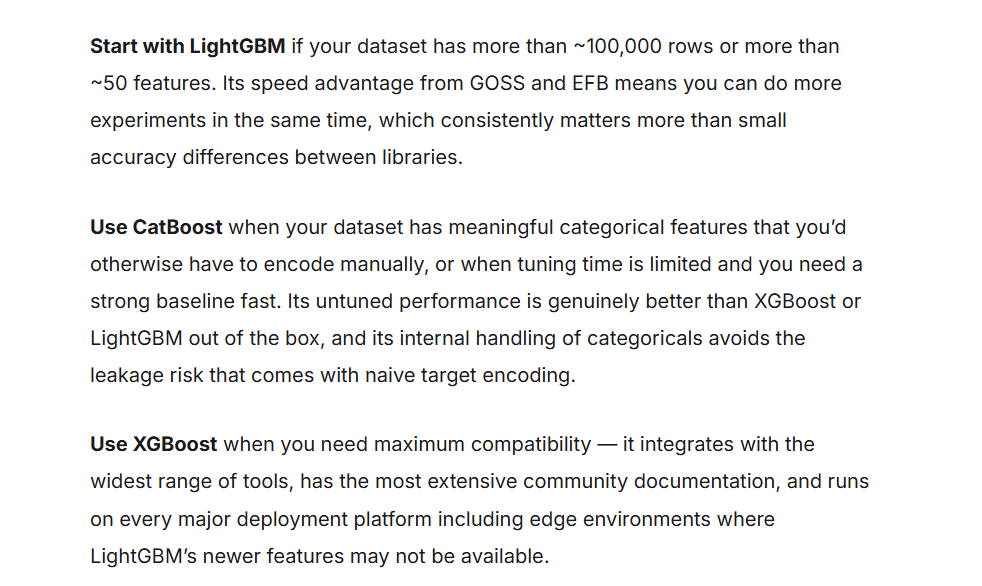

https://mlsimplified.com/gradient-boosting-xgboost-lightgbm-catboost/

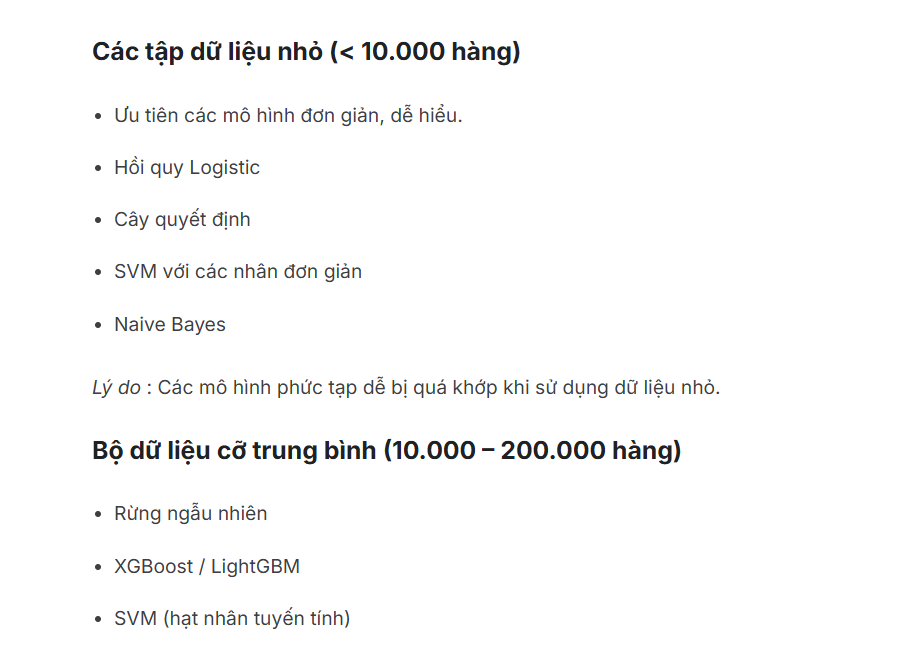
https://www.kaggle.com/discussions/general/637750

In [ ]:

# # 1. Điền giá trị thiếu cho cột holiday_name bằng nhãn cụ thể
# df_lgb['holiday_name'] = df_lgb['holiday_name'].fillna('Normal Day')

# # 2. Ép kiểu tất cả các cột dạng chữ (Categorical) sang kiểu 'category' của Pandas
# categorical_cols = ['store_type', 'region', 'season', 'holiday_name', 'store_id', 'department', 'is_holiday']
# for col in categorical_cols:
#     df_lgb[col] = df_lgb[col].astype('category')

# # 3. Lấy Log biến mục tiêu ngay từ đầu
# df_lgb['weekly_sales'] = np.log1p(df_lgb['weekly_sales'])


In [ ]:
# from sklearn.model_selection import train_test_split
# X = df_lgb.drop('weekly_sales', axis=1)
# y = df_lgb['weekly_sales']


# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# print(f"Training data shape: {X_train.shape}, {y_train.shape}")
# print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

In [ ]:
# from sklearn.preprocessing import RobustScaler


# scaler = RobustScaler()


# X_train_scaled = scaler.fit_transform(X_train)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)


# X_test_scaled = scaler.transform(X_test)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# print("Dữ liệu huấn luyện đã được chuẩn hóa (Robust Scaled):")
# print(X_train_scaled.shape)
# print("\nDữ liệu kiểm tra đã được chuẩn hóa (Robust Scaled):")
# print(X_test_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import numpy as np

model_lgb_explicit = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt', #Gradient Boosting Decision Tree
    num_leaves=20,
    max_depth=5,
    learning_rate=0.02,
    n_estimators=319,
    # min_child_weight=0.001, # Do không có đặc tính thời gian
    reg_alpha=0.08,
    reg_lambda=0.1,
    colsample_bytree=0.78,
    subsample=0.7,
    random_state=42,
    n_jobs=-1,
    importance_type='split',
)

# Train the model
model_lgb_explicit.fit(X_train_scaled, y_train_log)
# model_lgb_explicit.fit(X_train, y_train,categorical_feature=categorical_cols)


y_train_pred_lgb_explicit = model_lgb_explicit.predict(X_train_scaled)
# y_train_pred_lgb_explicit = model_lgb_explicit.predict(X_train)

# Evaluate train set performance
rmse_train_lgb_explicit = np.sqrt(mean_squared_error(y_train_log, y_train_pred_lgb_explicit))
mae_train_lgb_explicit = mean_absolute_error(y_train_log, y_train_pred_lgb_explicit)
r2_train_lgb_explicit = r2_score(y_train_log, y_train_pred_lgb_explicit)

print("--- LightGBM training Set Metrics (Explicit Hyperparameters) ---")
print(f"R-squared: {r2_train_lgb_explicit:.4f}")
print(f"RMSE: {rmse_train_lgb_explicit:.2f}")
print(f"MAE: {mae_train_lgb_explicit:.2f}")

# Make predictions on the test set
y_test_pred_lgb_explicit = model_lgb_explicit.predict(X_test_scaled)
# y_test_pred_lgb_explicit = model_lgb_explicit.predict(X_test)

# Evaluate test set performance
rmse_test_lgb_explicit = np.sqrt(mean_squared_error(y_test_log, y_test_pred_lgb_explicit))
mae_test_lgb_explicit = mean_absolute_error(y_test_log, y_test_pred_lgb_explicit)
r2_test_lgb_explicit = r2_score(y_test_log, y_test_pred_lgb_explicit)

print("--- LightGBM Testing Set Metrics (Explicit Hyperparameters) ---")
print(f"R-squared: {r2_test_lgb_explicit:.4f}")
print(f"RMSE: {rmse_test_lgb_explicit:.2f}")
print(f"MAE: {mae_test_lgb_explicit:.2f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2437
[LightGBM] [Info] Number of data points in the train set: 124800, number of used features: 26
[LightGBM] [Info] Start training from score 10.574351
--- LightGBM training Set Metrics (Explicit Hyperparameters) ---
R-squared: 0.5482
RMSE: 0.63
MAE: 0.52
--- LightGBM Testing Set Metrics (Explicit Hyperparameters) ---
R-squared: 0.5491
RMSE: 0.63
MAE: 0.52


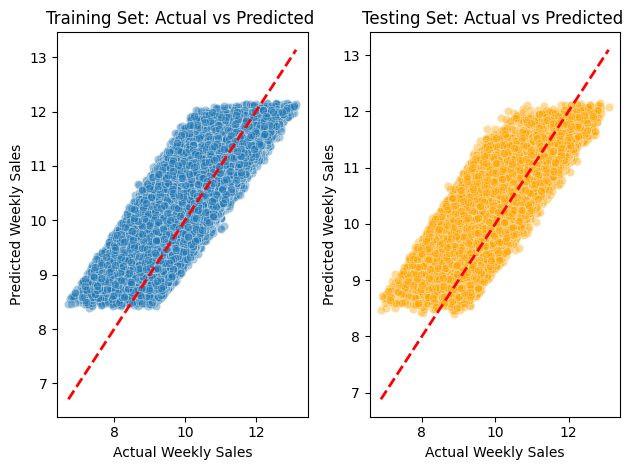

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Subplot 1: Training Data
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_log, y=y_train_pred_lgb_explicit, alpha=0.4)
plt.plot([y_train_log.min(), y_train_log.max()], [y_train_log.min(), y_train_log.max()], color='red', linestyle='--', lw=2)
plt.title('Training Set: Actual vs Predicted ')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')

# Subplot 2: Testing Data
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_log, y=y_test_pred_lgb_explicit, alpha=0.4, color='orange')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], color='red', linestyle='--', lw=2)
plt.title('Testing Set: Actual vs Predicted ')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')

plt.tight_layout()
plt.show()

Tại sao  thuật toán tăng cường như lightGBM lại cho ra kết quả tệ như vậy
* LightGBM học trên dữ liệu đã mã hóa One-Hot ( làm giảm tính tổng quát hóa của thuật toán)
* Sử dụng dữ liệu chuẩn hóa (đưa dữ liệu đã qua RobustScaler vào LightGBM tuy không làm sai lệch kết quả, nhưng nó làm mất đi ý nghĩa biểu diễn thực tế của các đặc trưng, khiến việc phân nhánh không đạt được hiệu năng tối đa.)
* Đây là bộ dữ liệu dự đoán theo thời gian thực vì thế đặc trưng thời gian là vô cùng quan trọng

In [ ]:
!pip install bayesian-optimization


import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer, r2_score, mean_absolute_error
from bayes_opt import BayesianOptimization
import numpy as np
import pandas as pd

def lgbm_cv_score(num_leaves, learning_rate, n_estimators, max_depth, subsample, colsample_bytree, reg_alpha, reg_lambda):

    num_leaves = int(num_leaves)
    n_estimators = int(n_estimators)
    max_depth = int(max_depth)

    # LightGBM model with current hyperparameters
    model = lgb.LGBMRegressor(
        objective='regression',
        boosting_type='gbdt',

        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth = int(max_depth),
        num_leaves = min(int(num_leaves), 2**max_depth - 1),
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1
    )


    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    scorer = make_scorer(r2_score, greater_is_better=True)

    # cv_results = cross_val_score(model, X_train_scaled, y_train_log, cv=kf, scoring=scorer, verbose=0)
    # cv_results = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', verbose=0)

    # Cách đúng để tối ưu R2 (Maximize R2)
    cv_results = cross_val_score(model, X_train_scaled, y_train_log, cv=kf, scoring='r2')
    return np.mean(cv_results)


pbounds = {
    'num_leaves': (20, 255), # < 20, cây quá nông, mô hình dễ bị underfitting,> 256-1, cây quá sâu dẫn đến overfitting rất nặng
    'learning_rate': (0.01, 0.2),
    'n_estimators': (100, 1500), # 100 là mức tối thiểu còn 1500 thì để thuật toán không chạy quá lâu gây tốn thời gian
    'max_depth': (5, 15), #giới hạn lý thuyết số lá sẽ là từ 32 (2^5) đến 32,768 (2^15) tránh cây phát triển quá lệch
    'subsample': (0.6, 1.0),# chọn >=6 vì để thuật toán vẫn có thể khái quát hóa nhưng không bị thiếu đặc trưng
    'colsample_bytree': (0.6, 1.0), # như trên
    'reg_alpha': (0.0, 1.0), # dự liệu lớn
    'reg_lambda': (0.0, 1.0)
}

optimizer = BayesianOptimization(
    f=lgbm_cv_score,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)


print("\n--- Running Bayesian Optimization for LightGBM ---")
optimizer.maximize(init_points=5, n_iter=20)

print("\n--- Best LightGBM Hyperparameters found by Bayesian Optimization ---")
best_params = optimizer.max['params']

best_params['num_leaves'] = int(best_params['num_leaves'])
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_depth'] = int(best_params['max_depth'])

print(best_params)


print("\n--- Training final LightGBM model with best parameters ---")
final_lgb_model = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_lgb_model.fit(X_train_scaled, y_train_log)
# final_lgb_model.fit(X_train, y_train,categorical_feature=categorical_cols)


y_test_pred_lgb_bo = final_lgb_model.predict(X_test_scaled)
# y_test_pred_lgb_bo = final_lgb_model.predict(X_test)

rmse_test_lgb_bo = np.sqrt(mean_squared_error(y_test_log, y_test_pred_lgb_bo))
mae_test_lgb_bo = mean_absolute_error(y_test_log, y_test_pred_lgb_bo)
r2_test_lgb_bo = r2_score(y_test_log, y_test_pred_lgb_bo)

print("\n--- LightGBM Testing Set Metrics (Bayesian Optimization) ---")
print(f"R-squared: {r2_test_lgb_bo:.4f}")
print(f"RMSE: {rmse_test_lgb_bo:.2f}")
print(f"MAE: {mae_test_lgb_bo:.2f}")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011460 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2435
[LightGBM] [Info] Number of data points in the train set: 99840, number of used features: 26
[LightGBM] [Info] Start training from score 10.572342
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

 Best LightGBM Hyperparameters found by Bayesian Optimization ---
{'num_leaves': 20, 'learning_rate': np.float64(0.02145159009586285), 'n_estimators': 319, 'max_depth': 5, 'subsample': np.float64(0.6995019757976164), 'colsample_bytree': np.float64(0.7759728068477483), 'reg_alpha': np.float64(0.08037058710881734), 'reg_lambda': np.float64(0.1)}


--- LightGBM Feature Importances ---
                      Feature  Importance
                   department        1158
                   store_size         922
                   is_holiday         501
                season_Summer         461
                season_Spring         418
                     store_id         250
                   markdown_5         201
                   markdown_4         200
                   markdown_1         192
                  temperature         190
        holiday_name_New Year         187
       holiday_name_Labor Day         162
      holiday_name_Normal Day         151
                   markdown_2         141
                   fuel_price         136
                 unemployment         130
                   markdown_3         118
                          cpi         109
holiday_name_Independence Day          92
                 store_type_B          86
                 store_type_C          77
                season_Winter         

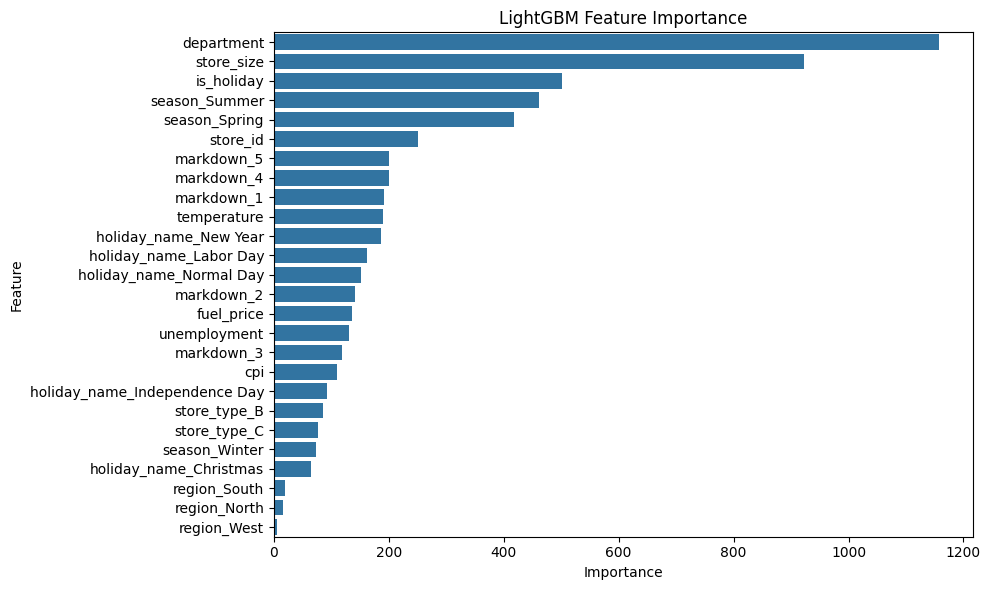


--- SHAP Values for LightGBM Model Interpretation ---


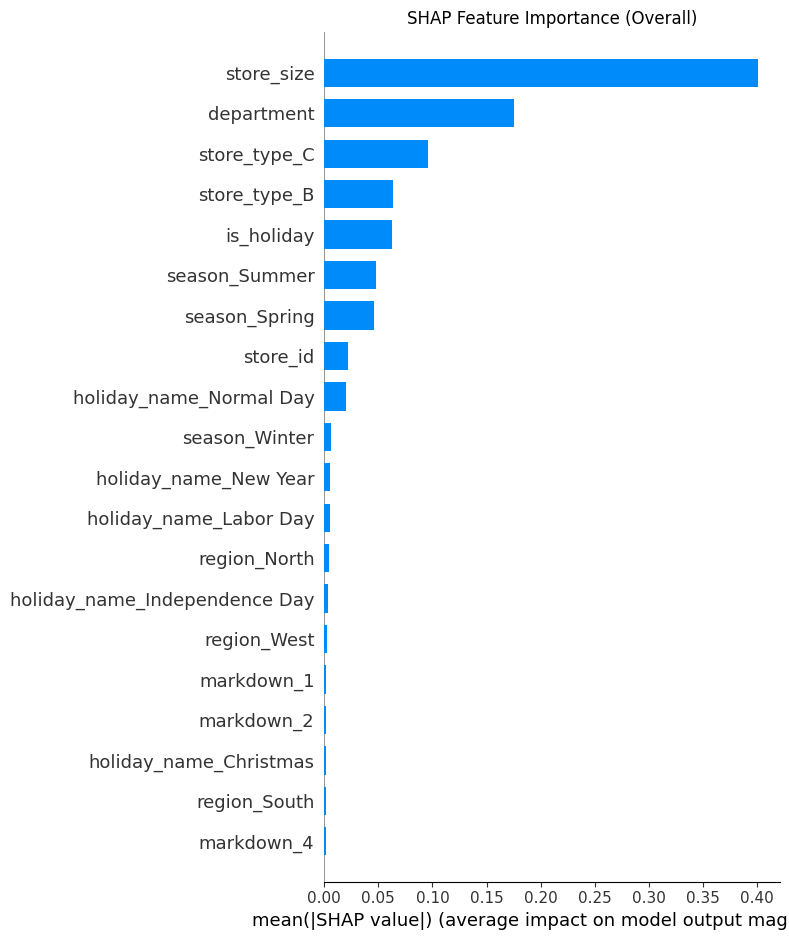

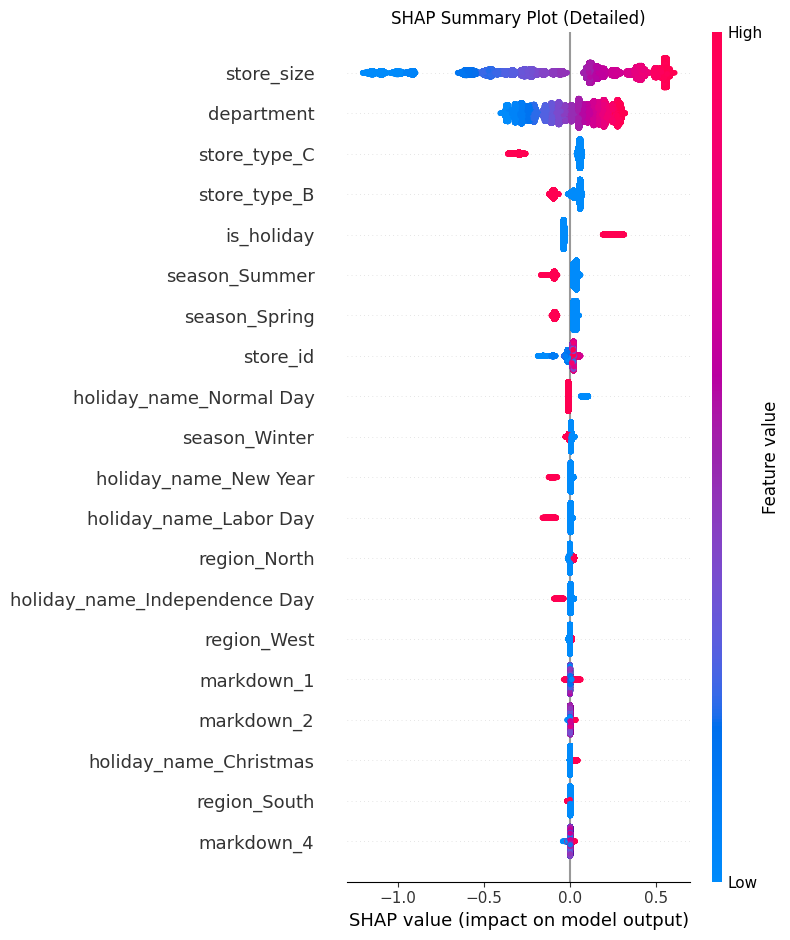

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("\n--- LightGBM Feature Importances ---")

feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': model_lgb_explicit.feature_importances_
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


print(feature_importance_df.to_string(index=False))


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n--- SHAP Values for LightGBM Model Interpretation ---")

explainer = shap.TreeExplainer(model_lgb_explicit)
shap_values = explainer.shap_values(X_train_scaled)
# shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train_scaled, feature_names=X_train_scaled.columns, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Overall)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_train_scaled, feature_names=X_train_scaled.columns, show=False)
# shap.summary_plot(shap_values, X_train, feature_names=X_train.columns, show=False)
plt.title('SHAP Summary Plot (Detailed)')
plt.tight_layout()
plt.show()



Lí do khiến kết quả lại thấp như vậy là do
* thuật toán LightGBM đang bị tuyến tính quá nhiều vì nếu có tương tác phi tuyến, màu đỏ và màu xanh trên biểu đồ SHAP sẽ trộn lẫn vào nhau ở những vùng ranh giới
* Thiếu đặc trưng thời gian
* Thuật toán gần như không học được mối quan hệ phi tuyến nào

##  Bảng so sánh hiệu năng
---

Dưới đây là bảng tổng hợp và so sánh kết quả giữa hai thuật toán **Linear Regression** và **LightGBM** dựa trên các chỉ số đo lường  từ quá trình thử nghiệm:

| Thuật toán (Algorithm) | Tập dữ liệu (Dataset) | R-squared ($R^2$) | RMSE | MAE |
| :--- | :--- | :---: | :---: | :---: |
| **Linear Regression** | Training Set | 0.5372 | 0.63 | 0.52 |
| | Testing Set | 0.5414 | 0.63 | 0.52 |
| **LightGBM** *(Explicit Params)* | Training Set | 0.5482 | 0.63 | 0.52 |
| | Testing Set | 0.5491 | 0.63 | 0.52 |


---

##  Nhận xét  =

* **Hiệu năng tương đương :** Cả hai mô hình đều có độ chính xác $R^2$ quanh mức **54%**. Điều này chứng minh rằng việc ép cấu trúc tuyến tính bằng *One-Hot Encoding* và *RobustScaler* đã vô tình làm giảm tính tổng quát hóa của thuật toán, khiến LightGBM cho ra kết quả không khác gì một phương trình hồi quy tuyến tính đơn giản.
* **Thiếu đặc trưng thời gian :** Doanh thu hàng tuần  phụ thuộc cực kỳ lớn vào tính chu kỳ. Do không có các biến biến đổi thời gian thực tế, cả hai mô hình đều bị giới hạn trần hiệu năng .